Este primer módulo constituye la fase de captura y acondicionamiento de las variables climáticas y de infraestructura fundamentales para el modelo.

A través de la API de Google Earth Engine (GEE), se programó el acceso a la colección histórica de reanálisis ERA5-Land para un horizonte temporal de 30 años (1996-2026), calculando de manera vectorizada la velocidad escalar media del recurso eólico a partir de sus componentes $U$ (viento zonal) y $V$ (viento meridional).

Variables:

1. Velocidad Media del viento (m/s):
viento medio / viento.

2. Pendiente del terreno (grados): Imagen raster de la pendiente calculada inicialmente del modelo digital de elevación (DEM) de Copernicuos GLO-30 / Pendiente_Corregida: versión mejorada de la imagen raster de la pendiente, reporyectada a UTM. / Pendiente_arr: array numérico que contiene los datos de la pendiente en GeoTIFF unificado exportado a Google Drive.

> Cabe recalcar que estos son datos brutos, mostrando todo Chile, los recortes se hicieron en los otros notebooks debido al limite de RAM dado por el software.

> existe una parte de limpieza de datos de GEE y Drive para eliminar duplicados y fallos.



In [1]:
# ============================================================
# PASO 0: Instalación y autenticación en Google Earth Engine
# ============================================================

# Instalar la API de GEE (ya disponible en Colab, pero por si acaso)
# !pip install earthengine-api --quiet

import ee
import geemap          # Para visualización interactiva
# !pip install geemap --quiet  # Si no está instalado

# Autenticar (solo la primera vez — abrirá un link para autorizar)
ee.Authenticate()

# Inicializar con tu proyecto GEE (debes tener uno creado en
# https://console.cloud.google.com con Earth Engine API activada)
# Reemplaza 'TU_PROYECTO_GEE' con el ID de tu proyecto real.
ee.Initialize(project='geoandres')  # <-- reemplazar

print("✅ Google Earth Engine inicializado correctamente")

✅ Google Earth Engine inicializado correctamente


In [2]:
# ============================================================
# PASO 1: Definir Área de Interés — Chile Continental
# ============================================================
# Usamos LSIB y filtramos explícitamente para evitar Rapa Nui
# y los fragmentos insulares lejanos que inflarían el bounding box
# con océano (el problema que mencionó José).

paises = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
chile = paises.filter(ee.Filter.eq('country_na', 'Chile'))

aoi_completo = chile.geometry()

# Bounding box de Chile continental aproximado (excluye Rapa Nui ~-109°W
# y el archipiélago Juan Fernández ~-80°W, que están fuera de este rango)
bbox_continental = ee.Geometry.Rectangle([-76.0, -56.0, -66.0, -17.0])

# Intersectamos: nos quedamos solo con la parte de Chile dentro de ese bbox
aoi = aoi_completo.intersection(bbox_continental, ee.ErrorMargin(1000))

# Verificación visual
Map = geemap.Map()
Map.centerObject(aoi, zoom=4)
Map.addLayer(aoi, {'color': 'red'}, 'Chile Continental (filtrado)')
Map.addLayer(aoi_completo, {'color': 'blue'}, 'Chile completo (con islas)', False)
Map

Map(center=[-35.999037052828065, -71.00358314814862], controls=(WidgetControl(options=['position', 'transparen…

In [3]:
# ============================================================
# PASO 2: Cargar ERA5-Land MENSUAL AGREGADO (no horario)
# ============================================================
# MONTHLY_AGGR ya viene promediado por mes → ~360 imágenes
# en vez de ~262,800 horarias. Esto es lo que evita el timeout.

fecha_inicio = '1996-04-01'
fecha_fin    = '2026-04-30'

era5_mensual = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                  .filterDate(fecha_inicio, fecha_fin)
                  .filterBounds(aoi)
                  .select(['u_component_of_wind_10m',
                           'v_component_of_wind_10m']))

n_imagenes = era5_mensual.size().getInfo()
print(f"Imágenes mensuales en la colección: {n_imagenes}")
# Esperado: ~360 (30 años * 12 meses)

Imágenes mensuales en la colección: 361


In [4]:
# ============================================================
# PASO 3: Calcular velocidad escalar del viento
# Fórmula: ws = sqrt(u10² + v10²)
# ============================================================

def calcular_velocidad_viento(image):
    """
    Transforma componentes vectoriales u,v en velocidad escalar.
    Retorna imagen con banda 'wind_speed' en m/s.
    """
    u = image.select('u_component_of_wind_10m')
    v = image.select('v_component_of_wind_10m')

    ws = (u.pow(2)
           .add(v.pow(2))
           .sqrt()
           .rename('wind_speed'))

    return image.addBands(ws).copyProperties(image, ['system:time_start'])

era5_ws = era5_mensual.map(calcular_velocidad_viento).select('wind_speed')

# Promedio de 30 años, ahora sobre solo ~360 imágenes (no 262,800)
viento_medio = era5_ws.mean().clip(aoi)

print("✅ Raster de velocidad media calculado (sin ejecutar aún sobre el servidor)")

✅ Raster de velocidad media calculado (sin ejecutar aún sobre el servidor)


In [5]:
# ============================================================
# PASO 4: Verificación rápida con reduceRegion (diagnóstico, no exportación)
# ============================================================
# bestEffort=True hace que GEE ajuste automáticamente la escala
# si 11132 m resulta demasiado fino para el tamaño del AOI completo.

stats = viento_medio.reduceRegion(
    reducer    = ee.Reducer.mean().combine(ee.Reducer.minMax(), '', True),
    geometry   = aoi,
    scale      = 11132,     # resolución nativa ERA5-Land (~0.1°)
    maxPixels  = 1e9,
    bestEffort = True
)

print("Estadísticas velocidad media viento (m/s), Chile continental, 30 años:")
print(stats.getInfo())

Estadísticas velocidad media viento (m/s), Chile continental, 30 años:
{'wind_speed_max': 8.31363159446961, 'wind_speed_mean': 1.56948481601157, 'wind_speed_min': 0.3329369287182321}


In [6]:
# ============================================================
# PASO 5: Exportar el raster final a Google Drive
# ============================================================
# Esto corre en el backend de GEE (asíncrono), no bloquea Colab
# y no tiene el límite de tiempo de una consulta interactiva.

tarea = ee.batch.Export.image.toDrive(
    image          = viento_medio,
    description    = 'ERA5_viento_medio_30a_chile',
    folder         = 'GEO3211_Eolico',
    fileNamePrefix = 'viento_medio_1996_2026',
    region         = aoi,
    scale          = 11132,
    crs            = 'EPSG:4326',
    maxPixels      = 1e10,
    fileFormat     = 'GeoTIFF'
)

tarea.start()
print("🚀 Tarea de exportación iniciada.")
print("Monitorea el progreso en: https://code.earthengine.google.com/tasks")

🚀 Tarea de exportación iniciada.
Monitorea el progreso en: https://code.earthengine.google.com/tasks


In [7]:
# ============================================================
# PASO 6: Monitorear el estado de la tarea desde el propio notebook
# ============================================================
# Opcional — evita tener que ir a la consola web constantemente.
# Ejecuta esta celda varias veces hasta que el estado sea 'COMPLETED'.

import time

while tarea.active():
    estado = tarea.status()['state']
    print(f"Estado actual: {estado}")
    time.sleep(30)

print("Estado final:", tarea.status())

Estado actual: READY
Estado actual: RUNNING
Estado final: {'state': 'COMPLETED', 'description': 'ERA5_viento_medio_30a_chile', 'priority': 100, 'creation_timestamp_ms': 1782235106385, 'update_timestamp_ms': 1782235156544, 'start_timestamp_ms': 1782235111890, 'task_type': 'EXPORT_IMAGE', 'destination_uris': ['https://drive.google.com/#folders/1HjSt3lrio4NleCiLuWp7QMvWc2w-OAFS'], 'attempt': 1, 'batch_eecu_usage_seconds': 59.97566604614258, 'id': 'FF2GWAPVCHQHFNG7PIITPXVL', 'name': 'projects/geoandres/operations/FF2GWAPVCHQHFNG7PIITPXVL'}


Mounted at /content/drive
CRS: EPSG:4326
Forma del array: (386, 93)
Velocidad media: 1.64 m/s
Velocidad máxima: 8.31 m/s
Velocidad mínima: 0.33 m/s


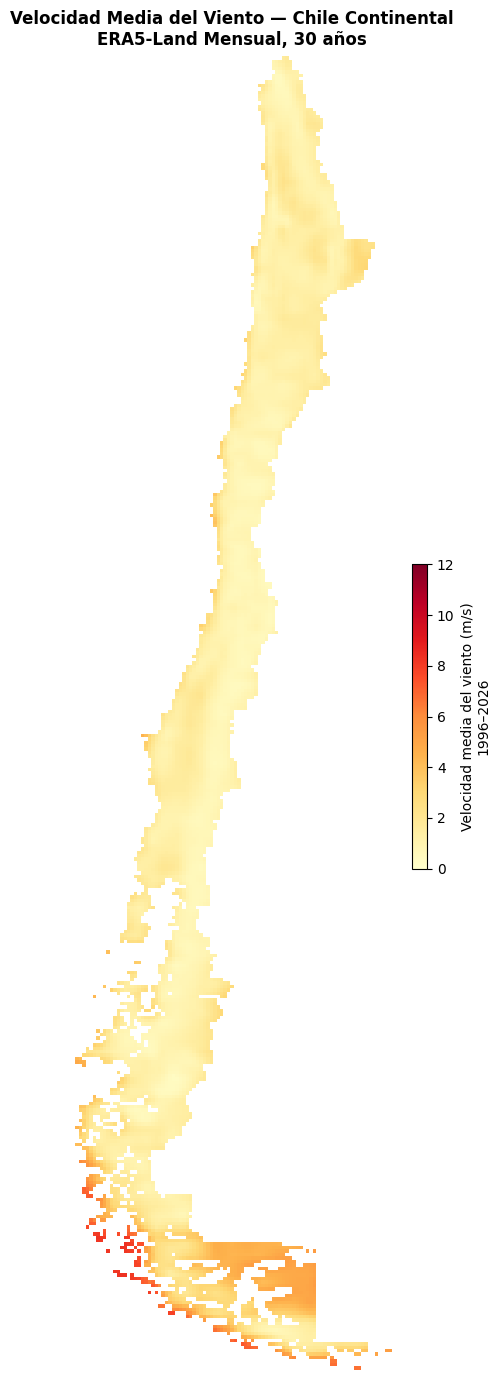

In [8]:
# ============================================================
# PASO 7: Leer el GeoTIFF exportado y visualizarlo en Colab
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import rasterio
import numpy as np
import matplotlib.pyplot as plt

ruta = '/content/drive/MyDrive/GEO3211_Eolico/viento_medio_1996_2026.tif'

with rasterio.open(ruta) as src:
    viento = src.read(1)
    nodata = src.nodata
    crs = src.crs
    transform = src.transform

viento = np.where(viento == nodata, np.nan, viento)

print(f"CRS: {crs}")
print(f"Forma del array: {viento.shape}")
print(f"Velocidad media: {np.nanmean(viento):.2f} m/s")
print(f"Velocidad máxima: {np.nanmax(viento):.2f} m/s")
print(f"Velocidad mínima: {np.nanmin(viento):.2f} m/s")

fig, ax = plt.subplots(figsize=(6, 14))
im = ax.imshow(viento, cmap='YlOrRd', vmin=0, vmax=12)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Velocidad media del viento (m/s)\n1996–2026', fontsize=10)
ax.set_title('Velocidad Media del Viento — Chile Continental\nERA5-Land Mensual, 30 años',
              fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEO3211_Eolico/viento_medio_mapa.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# PASO 1: Cargar el DEM — Copernicus GLO-30
# ============================================================
# Reutilizamos el mismo 'aoi' (Chile continental) ya definido
# en el pipeline del viento.

dem_collection = ee.ImageCollection('COPERNICUS/DEM/GLO30')

# GLO-30 viene en mosaicos (tiles), por eso es una ImageCollection.
# La unimos en un solo mosaico continuo sobre el AOI.
dem = dem_collection.select('DEM').mosaic().clip(aoi)

print("✅ DEM cargado y mosaicado sobre Chile continental")

✅ DEM cargado y mosaicado sobre Chile continental


In [10]:
# ============================================================
# PASO 2: Calcular la pendiente en grados
# ============================================================
# ee.Terrain.slope() ya viene implementado en GEE — usa el
# algoritmo estándar de diferencias finitas (Horn, 1981).

pendiente = ee.Terrain.slope(dem).rename('slope_degrees')

# Diagnóstico rápido — estadísticas sobre el AOI completo
stats_pendiente = pendiente.reduceRegion(
    reducer    = ee.Reducer.mean().combine(ee.Reducer.minMax(), '', True),
    geometry   = aoi,
    scale      = 90,        # ~3x la resolución nativa, para que el diagnóstico sea rápido
    maxPixels  = 1e9,
    bestEffort = True
)
print("Estadísticas de pendiente (grados), Chile continental:")
print(stats_pendiente.getInfo())

Estadísticas de pendiente (grados), Chile continental:
{'slope_degrees_max': 1.4650027751922607, 'slope_degrees_mean': 0.6535878750058188, 'slope_degrees_min': 0.0037907941732555628}


In [ ]:
# ============================================================
# DIAGNÓSTICO: Verificar el DEM crudo antes de calcular pendiente
# ============================================================

# 1. Revisar qué bandas tiene realmente el dataset
primera_imagen = dem_collection.first()
print("Bandas disponibles:", primera_imagen.bandNames().getInfo())

# 2. Estadísticas del DEM crudo (elevación en metros) sobre el AOI
stats_dem = dem.reduceRegion(
    reducer    = ee.Reducer.mean().combine(ee.Reducer.minMax(), '', True),
    geometry   = aoi,
    scale      = 90,
    maxPixels  = 1e9,
    bestEffort = True
)
print("Estadísticas DEM crudo (metros):")
print(stats_dem.getInfo())

Bandas disponibles: ['DEM', 'EDM', 'FLM', 'HEM', 'WBM']
Estadísticas DEM crudo (metros):
{'DEM_max': 6877.5908203125, 'DEM_mean': 1221.4075813544173, 'DEM_min': -243.960693359375}


In [ ]:
# ============================================================
# CORRECCIÓN: Reproyectar el DEM a un CRS en metros (UTM)
# antes de calcular la pendiente
# ============================================================
# Chile abarca varias zonas UTM (18S, 19S), pero para cálculos
# de terreno a escala nacional, usamos una proyección que minimice
# distorsión de escala en sentido N-S: EPSG:5361 (SIRGAS-Chile)
# o, más simple y robusto, forzamos una escala en metros explícita.

dem_metros = dem.reproject(crs='EPSG:32719', scale=30)
# EPSG:32719 = UTM zona 19S (cubre buena parte de Chile continental)

pendiente_corregida = ee.Terrain.slope(dem_metros).rename('slope_degrees')

# Volvemos a verificar
stats_pendiente_v2 = pendiente_corregida.reduceRegion(
    reducer    = ee.Reducer.mean().combine(ee.Reducer.minMax(), '', True),
    geometry   = aoi,
    scale      = 90,
    maxPixels  = 1e9,
    bestEffort = True
)
print("Estadísticas de pendiente corregida (grados):")
print(stats_pendiente_v2.getInfo())

Estadísticas de pendiente corregida (grados):
{'slope_degrees_max': 84.51202583481779, 'slope_degrees_mean': 13.01808173351631, 'slope_degrees_min': 0}


In [ ]:
# ============================================================
# EXPORTAR: Pendiente corregida a Google Drive
# ============================================================

tarea_pendiente = ee.batch.Export.image.toDrive(
    image          = pendiente_corregida,
    description    = 'pendiente_chile_continental',
    folder         = 'GEO3211_Eolico',
    fileNamePrefix = 'pendiente_grados',
    region         = aoi,
    scale          = 30,
    crs            = 'EPSG:32719',   # mantenemos UTM 19S, coherente con el cálculo
    maxPixels      = 1e10,
    fileFormat     = 'GeoTIFF'
)

tarea_pendiente.start()
print("🚀 Exportación de pendiente (corregida) iniciada.")
print("Monitorea en: https://code.earthengine.google.com/tasks")

🚀 Exportación de pendiente (corregida) iniciada.
Monitorea en: https://code.earthengine.google.com/tasks


In [ ]:
# ============================================================
# MONITOREAR el estado de la tarea
# ============================================================
import time

while tarea_pendiente.active():
    estado = tarea_pendiente.status()['state']
    print(f"Estado actual: {estado}")
    time.sleep(30)

print("Estado final:", tarea_pendiente.status())

NameError: name 'tarea_pendiente' is not defined

In [ ]:
# ============================================================
# Verificar qué archivos de pendiente existen en Drive
# ============================================================
import os

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'
archivos = [f for f in os.listdir(carpeta) if 'pendiente' in f.lower()]
print("Archivos de pendiente encontrados:")
for a in archivos:
    ruta_completa = os.path.join(carpeta, a)
    tamano_mb = os.path.getsize(ruta_completa) / (1024*1024)
    print(f"  {a} — {tamano_mb:.1f} MB")

Archivos de pendiente encontrados:
  pendiente_grados-0000000000-0000000000.tif — 976.1 MB
  pendiente_grados-0000032768-0000000000.tif — 763.5 MB
  pendiente_grados-0000065536-0000000000.tif — 777.6 MB
  pendiente_grados-0000098304-0000000000.tif — 766.4 MB
  pendiente_grados-0000131072-0000000000.tif — 242.5 MB
  pendiente_grados_90m-0000032768-0000000000.tif — 114.6 MB
  pendiente_grados_90m-0000000000-0000000000.tif — 283.4 MB
  pendiente_grados_90m-0000000000-0000000000 (1).tif — 283.4 MB
  pendiente_grados_90m-0000032768-0000000000 (1).tif — 114.6 MB
  pendiente_grados_90m_UNIFICADO.tif — 398.0 MB


In [ ]:
# Ejemplo: borrar un archivo viejo identificado como incorrecto
# (ajusta el nombre exacto según lo que veas en el listado)
os.remove('/content/drive/MyDrive/GEO3211_Eolico/pendiente_grados-0000065536-0000000000 (1).tif')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GEO3211_Eolico/pendiente_grados-0000065536-0000000000 (1).tif'

In [ ]:
# ============================================================
# RELANZAR: Exportación de pendiente a resolución más manejable
# ============================================================

tarea_pendiente = ee.batch.Export.image.toDrive(
    image          = pendiente_corregida,
    description    = 'pendiente_chile_continental_v2',
    folder         = 'GEO3211_Eolico',
    fileNamePrefix = 'pendiente_grados_90m',
    region         = aoi,
    scale          = 90,        # antes 30 m — ahora mucho más liviano
    crs            = 'EPSG:32719',
    maxPixels      = 1e9,        # también bajamos el límite, ya no se necesita 1e10
    fileFormat     = 'GeoTIFF'
)

tarea_pendiente.start()
print("🚀 Nueva tarea (90 m) iniciada con un nombre distinto para no confundir con las anteriores.")

🚀 Nueva tarea (90 m) iniciada con un nombre distinto para no confundir con las anteriores.


In [ ]:
# ============================================================
# EXPORTAR: Pendiente corregida, resolución 90 m
# ============================================================

tarea_pendiente = ee.batch.Export.image.toDrive(
    image          = pendiente_corregida,
    description    = 'pendiente_chile_continental_v2',
    folder         = 'GEO3211_Eolico',
    fileNamePrefix = 'pendiente_grados_90m',
    region         = aoi,
    scale          = 90,
    crs            = 'EPSG:32719',
    maxPixels      = 1e9,
    fileFormat     = 'GeoTIFF'
)

tarea_pendiente.start()
print("🚀 Nueva tarea (90 m) iniciada: pendiente_grados_90m.tif")

🚀 Nueva tarea (90 m) iniciada: pendiente_grados_90m.tif


In [ ]:
# ============================================================
# MONITOREAR el estado de la tarea
# ============================================================
import time

contador = 0
while tarea_pendiente.active():
    estado = tarea_pendiente.status()['state']
    print(f"[{contador} min] Estado actual: {estado}")
    time.sleep(60)      # cada 1 min, para no saturar de prints
    contador += 1

    if contador > 15:   # si pasa de 15 min en READY, avisa y corta el loop
        if estado == 'READY':
            print("⚠️ Lleva más de 15 min en READY — revisa la consola web manualmente.")
            break

print("Estado final:", tarea_pendiente.status())

[0 min] Estado actual: READY


KeyboardInterrupt: 

In [ ]:
# ============================================================
# DIAGNÓSTICO: Ver qué archivos existen realmente en la carpeta
# ============================================================
import os

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

if os.path.exists(carpeta):
    print(f"📁 Contenido de {carpeta}:\n")
    for archivo in sorted(os.listdir(carpeta)):
        ruta_completa = os.path.join(carpeta, archivo)
        tamano_mb = os.path.getsize(ruta_completa) / (1024*1024)
        print(f"  {archivo}  —  {tamano_mb:.1f} MB")
else:
    print(f"⚠️ La carpeta {carpeta} no existe")

📁 Contenido de /content/drive/MyDrive/GEO3211_Eolico:

  pendiente_grados-0000000000-0000000000.tif  —  976.1 MB
  pendiente_grados-0000032768-0000000000.tif  —  763.5 MB
  pendiente_grados-0000065536-0000000000.tif  —  777.6 MB
  pendiente_grados-0000098304-0000000000.tif  —  766.4 MB
  pendiente_grados-0000131072-0000000000.tif  —  242.5 MB
  pendiente_grados_90m-0000000000-0000000000 (1).tif  —  283.4 MB
  pendiente_grados_90m-0000000000-0000000000.tif  —  283.4 MB
  pendiente_grados_90m-0000032768-0000000000 (1).tif  —  114.6 MB
  pendiente_grados_90m-0000032768-0000000000.tif  —  114.6 MB
  pendiente_grados_90m_UNIFICADO.tif  —  398.0 MB
  viento_medio_1996_2026 (1).tif  —  0.1 MB
  viento_medio_1996_2026.tif  —  0.1 MB
  viento_medio_mapa.png  —  0.1 MB


In [ ]:
# ============================================================
# UNIR los tiles de pendiente_grados_90m en un solo GeoTIFF
# ============================================================
import rasterio
from rasterio.merge import merge
import glob

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

# Buscamos SOLO los tiles de la versión 90m, sin duplicados "(1)"
patron = f'{carpeta}/pendiente_grados_90m-*[0-9].tif'
tiles = sorted(glob.glob(patron))

print(f"Tiles encontrados para unir ({len(tiles)}):")
for t in tiles:
    print(f"  {t}")

# Abrir cada tile y fusionarlos
datasets = [rasterio.open(t) for t in tiles]
mosaico, transform_mosaico = merge(datasets)

# Tomar metadata de referencia del primer tile
perfil = datasets[0].profile.copy()
perfil.update({
    'height': mosaico.shape[1],
    'width':  mosaico.shape[2],
    'transform': transform_mosaico
})

# Guardar el raster unificado
ruta_final = f'{carpeta}/pendiente_grados_90m_UNIFICADO.tif'
with rasterio.open(ruta_final, 'w', **perfil) as dst:
    dst.write(mosaico)

# Cerrar los datasets abiertos
for d in datasets:
    d.close()

print(f"\n✅ Raster unificado guardado en: {ruta_final}")

Tiles encontrados para unir (2):
  /content/drive/MyDrive/GEO3211_Eolico/pendiente_grados_90m-0000000000-0000000000.tif
  /content/drive/MyDrive/GEO3211_Eolico/pendiente_grados_90m-0000032768-0000000000.tif

✅ Raster unificado guardado en: /content/drive/MyDrive/GEO3211_Eolico/pendiente_grados_90m_UNIFICADO.tif


In [ ]:
tiles = [
    f'{carpeta}/pendiente_grados_90m-0000000000-0000000000.tif',
    f'{carpeta}/pendiente_grados_90m-0000032768-0000000000.tif'
]

In [ ]:
# ============================================================
# VERIFICAR: Leer y validar el raster de pendiente UNIFICADO
# ============================================================
import rasterio
import numpy as np

ruta_pendiente_final = '/content/drive/MyDrive/GEO3211_Eolico/pendiente_grados_90m_UNIFICADO.tif'

with rasterio.open(ruta_pendiente_final) as src:
    pendiente_arr = src.read(1)
    nodata_p = src.nodata
    crs_p = src.crs
    transform_p = src.transform

pendiente_arr = np.where(pendiente_arr == nodata_p, np.nan, pendiente_arr)

print(f"CRS: {crs_p}")
print(f"Resolución: {transform_p[0]:.1f} m")
print(f"Forma del array: {pendiente_arr.shape}")
print(f"Pendiente media: {np.nanmean(pendiente_arr):.2f}°")
print(f"Pendiente máxima: {np.nanmax(pendiente_arr):.2f}°")
print(f"Pendiente mínima: {np.nanmin(pendiente_arr):.2f}°")

CRS: EPSG:32719
Resolución: 90.0 m
Forma del array: (47371, 7911)
Pendiente media: 13.02°
Pendiente máxima: 84.51°
Pendiente mínima: 0.00°


In [ ]:
# ============================================================
# VISUALIZAR: Mapa de pendiente — Chile Continental (versión final)
# ============================================================
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# Redefinir ruta y cargar el raster (código movido de celda anterior)
ruta_pendiente_final = '/content/drive/MyDrive/GEO3211_Eolico/pendiente_grados_90m_UNIFICADO.tif'

with rasterio.open(ruta_pendiente_final) as src:
    pendiente_arr = src.read(1)
    nodata_p = src.nodata
    # crs_p = src.crs # No se usa directamente en la visualización, pero es buena práctica mantener
    # transform_p = src.transform # Idem

pendiente_arr = np.where(pendiente_arr == nodata_p, np.nan, pendiente_arr)

fig, ax = plt.subplots(figsize=(6, 14))
im = ax.imshow(pendiente_arr, cmap='terrain', vmin=0, vmax=60)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Pendiente (grados)', fontsize=10)
ax.set_title('Pendiente del Terreno — Chile Continental\nDerivada de Copernicus DEM GLO-30 (90 m)',
              fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEO3211_Eolico/pendiente_mapa_final.png',
            dpi=200, bbox_inches='tight')
plt.show()

RasterioIOError: /content/drive/MyDrive/GEO3211_Eolico/pendiente_grados_90m_UNIFICADO.tif: No such file or directory

In [ ]:
# ============================================================
# UNIR tiles usando GDAL (más eficiente en memoria que rasterio.merge)
# ============================================================
import subprocess

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

tiles = [
    f'{carpeta}/pendiente_grados_90m-0000000000-0000000000.tif',
    f'{carpeta}/pendiente_grados_90m-0000032768-0000000000.tif'
]

ruta_final = f'{carpeta}/pendiente_grados_90m_UNIFICADO.tif'

comando = ['gdal_merge.py', '-o', ruta_final, '-co', 'COMPRESS=LZW'] + tiles

resultado = subprocess.run(comando, capture_output=True, text=True)
print(resultado.stdout)
print(resultado.stderr)

print(f"\n✅ Si no hay errores arriba, el archivo está en: {ruta_final}")

0...10...20...30...40...50...60...70...80...90...100 - done.



✅ Si no hay errores arriba, el archivo está en: /content/drive/MyDrive/GEO3211_Eolico/pendiente_grados_90m_UNIFICADO.tif


In [ ]:
!which gdal_merge.py || pip install gdal --break-system-packages --quiet

/usr/local/bin/gdal_merge.py


In [ ]:
# ============================================================
# VERIFICAR: Leer y validar el raster de pendiente UNIFICADO (vía GDAL)
# ============================================================
import rasterio
import numpy as np

ruta_pendiente_final = '/content/drive/MyDrive/GEO3211_Eolico/pendiente_grados_90m_UNIFICADO.tif'

with rasterio.open(ruta_pendiente_final) as src:
    pendiente_arr = src.read(1)
    nodata_p = src.nodata
    crs_p = src.crs
    transform_p = src.transform

pendiente_arr = np.where(pendiente_arr == nodata_p, np.nan, pendiente_arr)

print(f"CRS: {crs_p}")
print(f"Resolución: {transform_p[0]:.1f} m")
print(f"Forma del array: {pendiente_arr.shape}")
print(f"Pendiente media: {np.nanmean(pendiente_arr):.2f}°")
print(f"Pendiente máxima: {np.nanmax(pendiente_arr):.2f}°")
print(f"Pendiente mínima: {np.nanmin(pendiente_arr):.2f}°")

CRS: EPSG:32719
Resolución: 90.0 m
Forma del array: (47371, 7911)
Pendiente media: 13.02°
Pendiente máxima: 84.51°
Pendiente mínima: 0.00°


In [ ]:
# ============================================================
# VISUALIZAR: Mapa de pendiente — Chile Continental (versión final)
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 14))
im = ax.imshow(pendiente_arr, cmap='terrain', vmin=0, vmax=60)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Pendiente (grados)', fontsize=10)
ax.set_title('Pendiente del Terreno — Chile Continental\nDerivada de Copernicus DEM GLO-30 (90 m)',
              fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEO3211_Eolico/pendiente_mapa_final.png',
            dpi=200, bbox_inches='tight')
plt.show()